In [2]:
import sys
sys.path.append('../code')

import os

import matplotlib.pyplot as plt
import numpy as np
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph

from tqdm import tqdm

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [3]:
data_path =  '/users/ntolley/data/ntolley/dendractor/random_initialization_memorycontext'
file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict

100%|██████████| 7/7 [00:07<00:00,  1.05s/it]


In [61]:
res_dict = random_init_dict['cuesoma_contextsoma']
# res_dict = random_init_dict['cuedend_contextdend']
# res_dict = random_init_dict['cuedend_contextdend_celldend']


name = res_dict['name']
output_array = res_dict['output_array']
targets = res_dict['targets']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]
print(name)

cuesoma_contextsoma


In [62]:
t_max = 2000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [63]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)


num_model_sims = 15

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_model_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_model_sims)])
model.fit(rate_fit, target_fit)

# for sim_idx in range(num_model_sims, len(x_train)):
for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])

    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)

print(error_list)

[0.1511895838247862, 0.14157234660820883, 0.147956422012835, 0.1472365212636212, 0.147032609726103, 0.15768801434951593, 0.17200252563132307, 0.14424013050363255, 0.1396360565276087, 0.15187019367195956, 0.14421333940354375, 0.140863797377772, 0.14282462424450304, 0.1460257160922707, 0.14243176186486028, 0.1623588481992859, 0.15681564851198568, 0.15524319611434506, 0.15692786177864385, 0.14570158030604732]


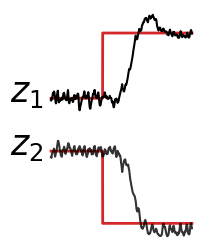

In [89]:
start_idx = 26_800
stop_idx = 27_900

# stop_idx = None
# stop_idx = 10_000

plt.figure(figsize=(2,3))
plt.subplot(2,1,1)
plt.plot(targets[burn_in+start_idx:burn_in+stop_idx,0], color='C3', linewidth=2)
plt.plot(y_pred[start_idx:stop_idx,0], color='k', linewidth=1.5)
plt.text(-320,-0.1,'$z_1$', fontsize=25)
plt.axis('off')

plt.subplot(2,1,2)
plt.plot(targets[burn_in+start_idx:burn_in+stop_idx,1], color='C3', linewidth=2)
plt.plot(y_pred[start_idx:stop_idx,1], color='k', alpha=0.8, linewidth=1.5)
plt.text(-320,-0.1,'$z_2$', fontsize=25)
# plt.xlim(plt.xlim()[0] - 300)

plt.axis('off')

plt.savefig('simple_task_trajectory.svg')

